# Medical Data Analysis with Python

Welcome to the Medical Data Analysis notebook! In this notebook, we will use the Breast Cancer Wisconsin (Diagnostic) dataset to answer medical-related questions through data analysis and visualization.

## Table of Contents
1. [Introduction](#introduction)
2. [Installing the Libraries](#installing-the-libraries)
3. [Importing the Libraries](#importing-the-libraries)
4. [Loading and Exploring the Dataset](#loading-and-exploring-the-dataset)
5. [Data Cleaning](#data-cleaning)
6. [Basic Data Visualization](#basic-data-visualization)
7. [Advanced Data Analysis](#advanced-data-analysis)
8. [Conclusion](#conclusion)

Let's get started!

## Introduction

In this notebook, we will analyze the Breast Cancer Wisconsin (Diagnostic) dataset to address questions related to cancer diagnosis. We will perform tasks such as data exploration, visualization, and basic statistical analysis.

## Installing the Libraries

Make sure you have the necessary libraries installed. You can use the following command to install them if needed.

In [1]:
# Uncomment and run the following line to install the libraries if needed:
# !pip install seaborn matplotlib scikit-learn pandas


## Importing the Libraries

Let's import the necessary libraries for data analysis and visualization.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Check versions to confirm installation
print("Seaborn version:", sns.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Pandas version:", pd.__version__)


Seaborn version: 0.12.2
Matplotlib version: 3.7.2
Pandas version: 2.0.3


## Loading and Exploring the Dataset

We'll load the Breast Cancer Wisconsin (Diagnostic) dataset and perform initial exploration to understand its structure and content.

### TODO: Load the dataset and display the first few rows.
The dataset is available through scikit-learn's dataset module.

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Display the first few rows of the dataset
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


### Data Description

The dataset contains various features related to breast cancer tumors, including measurements of cell nuclei. The target variable indicates whether the tumor is malignant or benign.

## Data Cleaning

Before performing any analysis, it is important to clean the data. We need to check for missing values and perform any necessary preprocessing.

### TODO: Check for missing values in the dataset.

In [4]:
# Check for missing values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

### Basic Data Visualization

Let's create some basic visualizations to better understand the dataset.

### TODO: Create a histogram of the 'mean radius' feature, separated by tumor type.

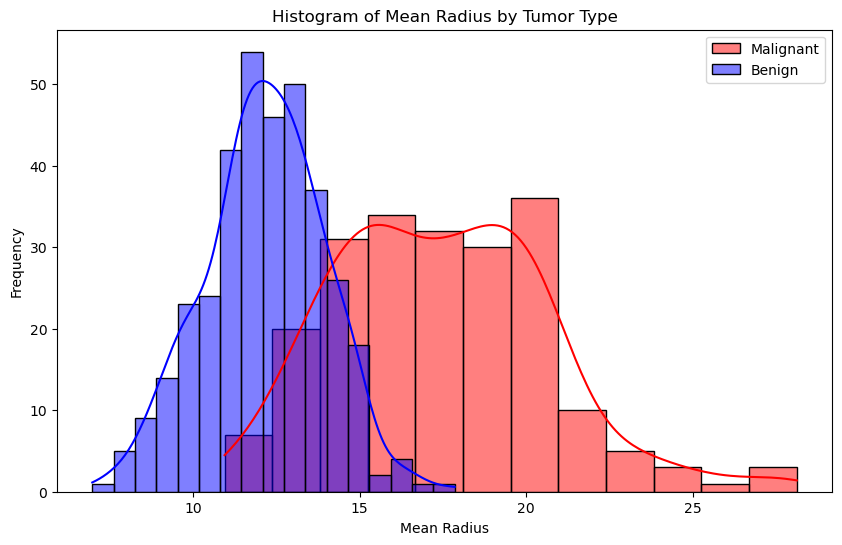

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['target'] == 'malignant']['mean radius'], color='red', label='Malignant', kde=True)
sns.histplot(df[df['target'] == 'benign']['mean radius'], color='blue', label='Benign', kde=True)
plt.title('Histogram of Mean Radius by Tumor Type')
plt.xlabel('Mean Radius')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### TODO: Create a pairplot of selected features to visualize relationships between them, colored by tumor type.
Use features such as 'mean radius', 'mean texture', and 'mean smoothness'.

/home/marc/anaconda3/envs/datascience/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


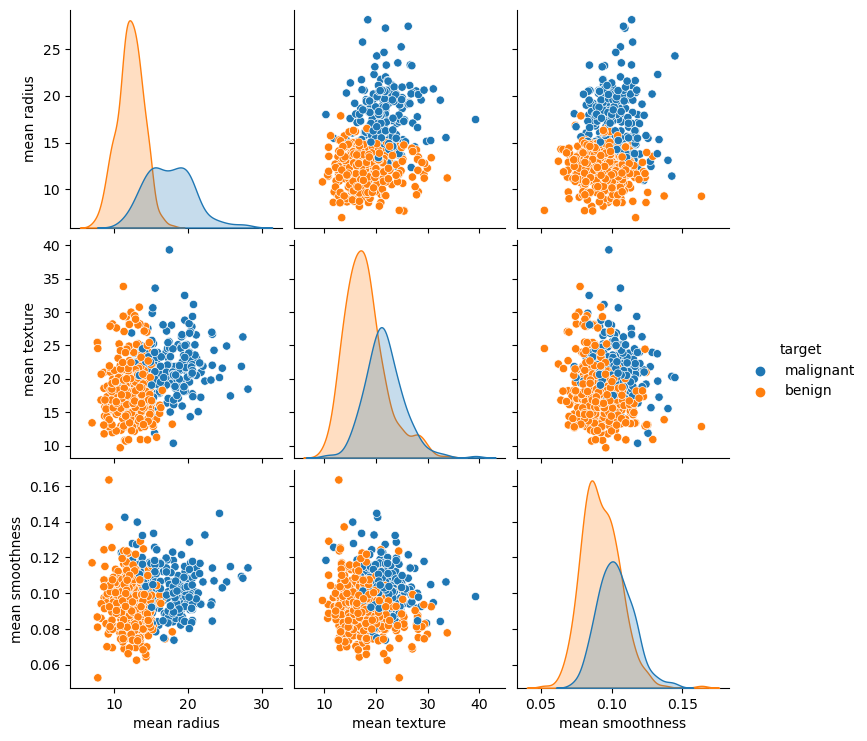

In [6]:
selected_features = ['mean radius', 'mean texture', 'mean smoothness', 'target']
sns.pairplot(df[selected_features], hue='target')
plt.show()

## Advanced Data Analysis

Let's delve deeper into the dataset with some advanced analysis and visualization.

### TODO: Create a correlation heatmap of the numerical features.
Visualize how different features correlate with each other.

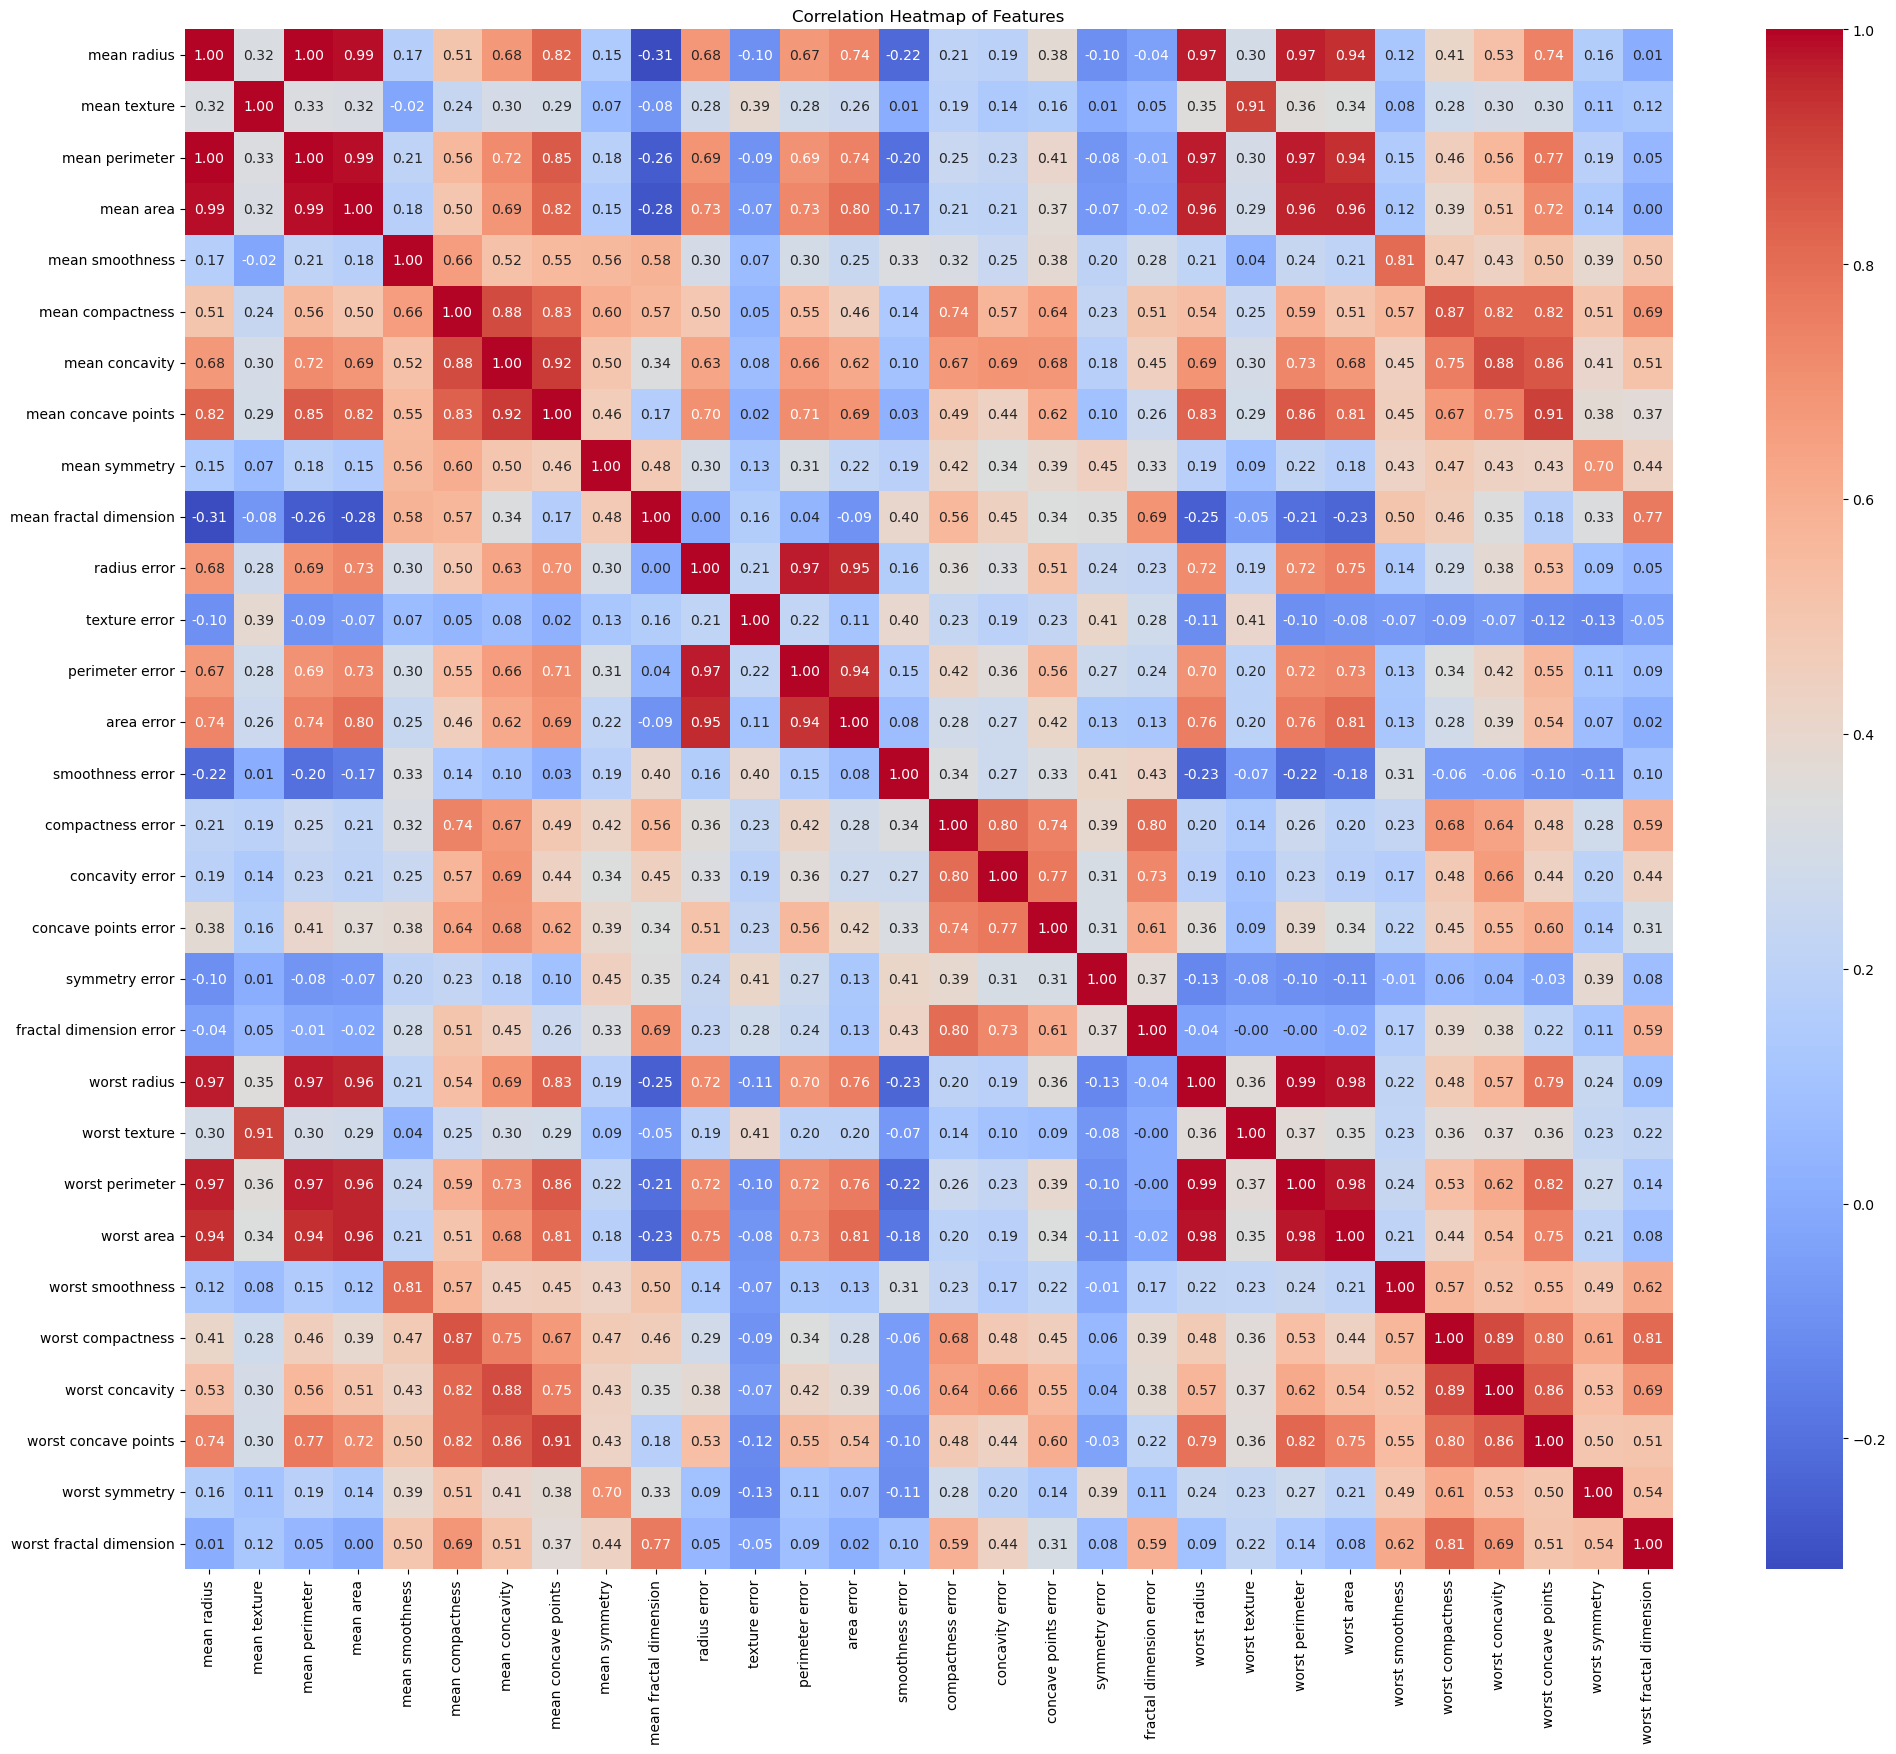

In [7]:
correlation_matrix = df.drop(columns='target').corr()
plt.figure(figsize=(24, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

### TODO: Perform a basic statistical analysis to compare mean values of features between malignant and benign tumors.
Use descriptive statistics methods like mean and standard deviation.

In [8]:
malignant_df = df[df['target'] == 'malignant']
benign_df = df[df['target'] == 'benign']

malignant_stats = malignant_df.describe().T
benign_stats = benign_df.describe().T

comparison_stats = pd.concat([malignant_stats['mean'], benign_stats['mean']], axis=1, keys=['Malignant', 'Benign'])
comparison_stats

,Malignant,Benign
mean radius,17.462830,12.146524
mean texture,21.604906,17.914762
mean perimeter,115.365377,78.075406
mean area,978.376415,462.790196
mean smoothness,0.102898,0.092478
mean compactness,0.145188,0.080085
mean concavity,0.160775,0.046058
mean concave points,0.087990,0.025717
mean symmetry,0.192909,0.174186
mean fractal dimension,0.062680,0.062867


## Conclusion

In this notebook, you've learned how to perform data analysis and visualization on the Breast Cancer Wisconsin (Diagnostic) dataset. We explored the dataset, visualized key features, and performed advanced analysis to uncover insights related to breast cancer diagnosis. Continue exploring and practicing with different datasets to enhance your data analysis skills. Happy analyzing!